## Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import random

from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

## Setting

In [ ]:
CFG = {
    'BATCH_SIZE': 4096,
    'EPOCHS': 20,
    'LEARNING_RATE': 1e-3,
    'SEED' : 42
}
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['SEED']) # Seed 고정

## Data Load

In [ ]:
# 데이터 로드
all_train = pd.read_parquet("/content/drive/MyDrive/토스챌린지/train.parquet", engine="pyarrow")
test = pd.read_parquet("/content/drive/MyDrive/토스챌린지/test.parquet", engine="pyarrow").drop(columns=['ID'])

print("Train shape:", all_train.shape)
print("Test shape:", test.shape)

Train shape: (10704179, 119)
Test shape: (1527298, 118)


## Data Down-Sampling

In [ ]:
# from sklearn.decomposition import PCA
# import numpy as np

# print("Strategy 1: Applying PCA for dimensionality reduction...")

# # PCA를 적용할 피처 그룹 정의
# group1_cols = [col for col in all_train.columns if 'history_b_' in col]
# group2_cols = [col for col in all_train.columns if 'history_a_' in col]

# # ================= ✨ 에러 해결 코드 시작 ✨ =================
# print("Handling missing values (NaNs) before PCA...")

# # 1. 학습 데이터(all_train)에서만 각 컬럼의 평균을 계산합니다.
# g1_means = all_train[group1_cols].mean()
# g2_means = all_train[group2_cols].mean()

# # 2. 계산된 평균값으로 train과 test 데이터의 결측치를 모두 채웁니다.
# all_train[group1_cols] = all_train[group1_cols].fillna(g1_means)
# test[group1_cols] = test[group1_cols].fillna(g1_means)

# all_train[group2_cols] = all_train[group2_cols].fillna(g2_means)
# test[group2_cols] = test[group2_cols].fillna(g2_means)

# print("Missing values handled.")
# # ================= ✨ 에러 해결 코드 종료 ✨ =================


# # PCA 모델 초기화
# pca_g1 = PCA(n_components=1, random_state=42)
# pca_g2 = PCA(n_components=1, random_state=42)

# # 이제 결측치가 없는 데이터로 PCA를 학습합니다.
# pca_g1.fit(all_train[group1_cols])
# pca_g2.fit(all_train[group2_cols])

# # fit된 모델을 사용해 train/test 데이터 모두에 transform을 적용합니다.
# all_train['history_b_pca'] = pca_g1.transform(all_train[group1_cols])
# test['history_b_pca'] = pca_g1.transform(test[group1_cols])

# all_train['history_a_pca'] = pca_g2.transform(all_train[group2_cols])
# test['history_a_pca'] = pca_g2.transform(test[group2_cols])

# print("PCA components 'history_b_pca', 'history_a_pca' created.")
# print("New train shape:", all_train.shape)

Strategy 1: Applying PCA for dimensionality reduction...
Handling missing values (NaNs) before PCA...
Missing values handled.
PCA components 'history_b_pca', 'history_a_pca' created.
New train shape: (10704179, 121)


In [ ]:
# print("\nStrategy 2: Creating ratio and difference features...")

# # 0으로 나누는 것을 방지하기 위해 작은 값(epsilon)을 더해줍니다.
# epsilon = 1e-6

# # 루프를 돌며 train/test 데이터프레임에 동일하게 적용
# for df in [all_train, test]:
#     # 비율 피처 생성
#     df['ratio_hist_ba_pca'] = df['history_b_pca'] / (df['history_a_pca'] + epsilon)

#     # 차이 피처 생성
#     df['diff_hist_ba_pca'] = df['history_b_pca'] - df['history_a_pca']

# print("Ratio and difference features ('ratio_hist_ba_pca', 'diff_hist_ba_pca') created.")
# print("New train shape:", all_train.shape)


Strategy 2: Creating ratio and difference features...
Ratio and difference features ('ratio_hist_ba_pca', 'diff_hist_ba_pca') created.
New train shape: (10704179, 123)


In [ ]:
# print("\nStrategy 3: Creating interaction features with independent columns...")

# # 독립적인 피처 그룹으로 판단된 'feat_c' 그룹의 일부를 예시로 사용합니다.
# independent_cols = ['feat_c_1', 'feat_c_2', 'feat_c_3'] # 예시 피처
# pca_cols = ['history_b_pca', 'history_a_pca']

# # 루프를 돌며 train/test 데이터프레임에 동일하게 적용
# for df in [all_train, test]:
#     for p_col in pca_cols:
#         for i_col in independent_cols:
#             # 곱셈을 통해 간단한 상호작용 피처를 생성합니다.
#             df[f'interaction_{p_col}_x_{i_col}'] = df[p_col] * df[i_col]

# print(f"Interaction features created between PCA components and {independent_cols}.")
# print("New train shape:", all_train.shape)


Strategy 3: Creating interaction features with independent columns...
Interaction features created between PCA components and ['feat_c_1', 'feat_c_2', 'feat_c_3'].
New train shape: (10704179, 129)


In [ ]:
# print(f"Dropping {len(group1_cols) + len(group2_cols)} original columns...")
# all_train.drop(columns=group1_cols + group2_cols, inplace=True)
# test.drop(columns=group1_cols + group2_cols, inplace=True)

Dropping 37 original columns...


In [ ]:
# clicked == 1 데이터
clicked_1 = all_train[all_train['clicked'] == 1]

# clicked == 0 데이터에서 동일 개수x2 만큼 무작위 추출 (다운 샘플링)
clicked_0 = all_train[all_train['clicked'] == 0].sample(n=len(clicked_1)*2, random_state=42)

# 두 데이터프레임 합치기
train = pd.concat([clicked_1, clicked_0], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

Strategy 1: Selecting features based on LightGBM importance...
Converting object columns to numeric using Label Encoding...
Object columns converted.


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


Top 30 Feature Importances:
         feature  importance
0   inventory_id        1868
1    history_a_1         954
2       feat_e_3         926
3       feat_d_4         693
4       feat_c_8         684
5       feat_e_2         662
6       feat_c_2         642
7      feat_a_14         640
8       feat_b_6         614
9           hour         599
10      l_feat_6         571
11      l_feat_7         565
12      feat_b_3         563
13     l_feat_10         558
14      l_feat_9         551
15     l_feat_15         531
16      feat_c_5         530
17      feat_e_9         526
18      feat_c_3         525
19      feat_e_7         509
20     l_feat_14         498
21   history_b_1         493
22      feat_b_1         487
23     l_feat_12         484
24      feat_b_5         477
25     l_feat_11         473
26     feat_e_10         472
27      feat_e_8         464
28      l_feat_5         448
29      feat_b_2         447

Selected top 70 features based on LightGBM.


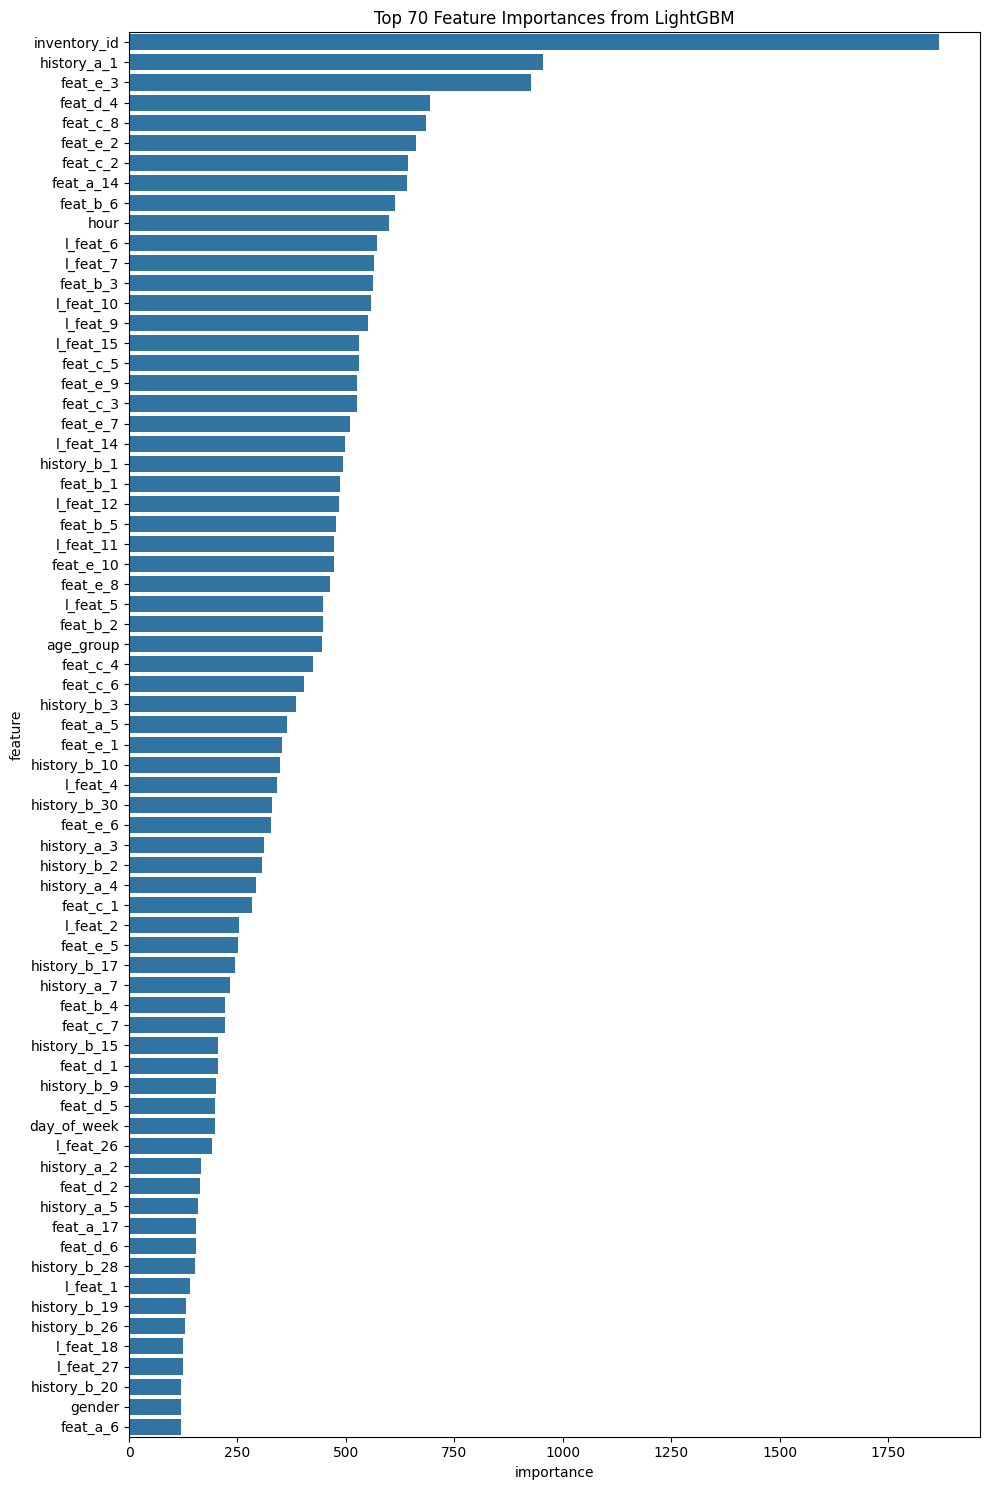

In [ ]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # LabelEncoder import 추가

print("Strategy 1: Selecting features based on LightGBM importance...")

# 학습에 사용할 전체 피처 목록을 먼저 정의합니다.
target_col = "clicked"
seq_col = "seq"
FEATURE_EXCLUDE = {target_col, seq_col, "ID"}
feature_cols = [c for c in train.columns if c not in FEATURE_EXCLUDE]

# ✨ [수정] 이 부분이 추가되었습니다.
# -------------------------------------------------------------------
# LightGBM이 처리할 수 있도록 object 타입의 컬럼들을 Label Encoding으로 변환합니다.
print("Converting object columns to numeric using Label Encoding...")
object_cols = [col for col in feature_cols if train[col].dtype == 'object']

for col in object_cols:
    encoder = LabelEncoder()
    # .astype(str)을 붙여주어 혹시 모를 결측치나 다른 타입을 문자열로 통일 후 인코딩합니다.
    train[col] = encoder.fit_transform(train[col].astype(str))
print("Object columns converted.")
# -------------------------------------------------------------------

# 피처 선택을 위해 다운 샘플링된 train 데이터를 사용합니다.
X = train[feature_cols]
y = train[target_col]

# LightGBM 모델 학습
model_lgb = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    verbose=-1
)

model_lgb.fit(X, y,
              eval_set=[(X, y)],
              callbacks=[lgb.early_stopping(100, verbose=False)])

# 피처 중요도 추출
feature_importances = pd.DataFrame(
    {'feature': feature_cols, 'importance': model_lgb.feature_importances_}
).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 30 Feature Importances:")
print(feature_importances.head(30))

# 상위 70개 피처 선택
top_n = 70
lgb_top_features = feature_importances['feature'][:top_n].tolist()

print(f"\nSelected top {top_n} features based on LightGBM.")

# 피처 중요도 시각화
plt.figure(figsize=(10, 15))
sns.barplot(x='importance', y='feature', data=feature_importances.head(top_n))
plt.title(f'Top {top_n} Feature Importances from LightGBM')
plt.tight_layout()
plt.show()

In [ ]:
print("Train shape:", train.shape)
print("Train clicked:0:", train[train['clicked']==0].shape)
print("Train clicked:1:", train[train['clicked']==1].shape)

Train shape: (612537, 92)
Train clicked:0: (408358, 92)
Train clicked:1: (204179, 92)


## Data Column Setting

In [ ]:
# Target / Sequence
target_col = "clicked"
seq_col = "seq"

# 학습에 사용할 피처: ID/seq/target 제외, 나머지 전부
FEATURE_EXCLUDE = {target_col, seq_col, "ID"}
feature_cols = [c for c in train.columns if c not in FEATURE_EXCLUDE]

print("Num features:", len(feature_cols))
print("Sequence:", seq_col)
print("Target:", target_col)

# 데이터 로드 후
scaler = StandardScaler()

# train 데이터에 맞춰 스케일링 기준을 학습하고, train/test에 모두 적용
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols]) # test는 transform만 사용

Num features: 90
Sequence: seq
Target: clicked


## Define Custom Dataset

In [ ]:
class ClickDataset(Dataset):
    def __init__(self, df, feature_cols, seq_col, target_col=None, has_target=True):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.seq_col = seq_col
        self.target_col = target_col
        self.has_target = has_target

        # 비-시퀀스 피처: 전부 연속값으로
        self.X = self.df[self.feature_cols].astype(float).fillna(0).values

        # 시퀀스: 문자열 그대로 보관 (lazy 파싱)
        self.seq_strings = self.df[self.seq_col].astype(str).values

        if self.has_target:
            self.y = self.df[self.target_col].astype(np.float32).values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float)

        # 전체 시퀀스 사용 (빈 시퀀스만 방어)
        s = self.seq_strings[idx]
        if s:
            arr = np.fromstring(s, sep=",", dtype=np.float32)
        else:
            arr = np.array([], dtype=np.float32)

        if arr.size == 0:
            arr = np.array([0.0], dtype=np.float32)  # 빈 시퀀스 방어

        seq = torch.from_numpy(arr)  # shape (seq_len,)

        if self.has_target:
            y = torch.tensor(self.y[idx], dtype=torch.float)
            return x, seq, y
        else:
            return x, seq

In [ ]:
def collate_fn_train(batch):
    xs, seqs, ys = zip(*batch)
    xs = torch.stack(xs)
    ys = torch.stack(ys)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)  # 빈 시퀀스 방지
    return xs, seqs_padded, seq_lengths, ys

def collate_fn_infer(batch):
    xs, seqs = zip(*batch)
    xs = torch.stack(xs)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)
    return xs, seqs_padded, seq_lengths

## Define Model Architecture

In [ ]:
class TabularSeqModel(nn.Module):
    def __init__(self, d_features, lstm_hidden=32, hidden_units=[1024, 512, 256, 128], dropout=0.2):
        super().__init__()
        # 모든 비-시퀀스 피처에 BN
        self.bn_x = nn.BatchNorm1d(d_features)
        # seq: 숫자 시퀀스 → LSTM
        self.lstm = nn.GRU(input_size=1, hidden_size=lstm_hidden, batch_first=True, bidirectional = True)

        # 최종 MLP
        input_dim = d_features + lstm_hidden * 2
        layers = []
        for h in hidden_units:
            layers += [nn.Linear(input_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            input_dim = h
        layers += [nn.Linear(input_dim, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_feats, x_seq, seq_lengths):
        x = self.bn_x(x_feats)

        x_seq = x_seq.unsqueeze(-1)
        packed = nn.utils.rnn.pack_padded_sequence(
            x_seq, seq_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # 1. GRU의 출력을 올바르게 받습니다. (cell state 'c_n'이 없습니다)
        _, h_n = self.lstm(packed) # self.lstm을 self.gru로 바꾸셨다면 이 부분도 수정

        # 2. 양방향(forward, backward) 출력을 합쳐줍니다.
        # h_n shape: (2, batch_size, hidden_size) -> (batch_size, 2, hidden_size)
        h_n = h_n.permute(1, 0, 2)

        # (batch_size, 2, hidden_size) -> (batch_size, 2 * hidden_size)
        h = h_n.reshape(h_n.size(0), -1)

        # 이제 x(2D)와 h(2D) 모두 2차원 텐서가 되어 정상적으로 합쳐집니다.
        z = torch.cat([x, h], dim=1)
        return self.mlp(z).squeeze(1)

## Train / Validation

In [ ]:
def train_model(train_df, feature_cols, seq_col, target_col,
                batch_size=512, epochs=3, lr=1e-3, device="cuda"):

    # 1) split
    tr_df, va_df = train_test_split(train_df, test_size=0.2, random_state=42, shuffle=True)

    # 2) Dataset / Loader (l_max 인자 제거)
    train_dataset = ClickDataset(tr_df, feature_cols, seq_col, target_col, has_target=True)
    val_dataset   = ClickDataset(va_df, feature_cols, seq_col, target_col, has_target=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn_train)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn_train)

    # 3) 모델
    d_features = len(feature_cols)
    model = TabularSeqModel(d_features=d_features, lstm_hidden=64, hidden_units=[256,128], dropout=0.2).to(device)
    pos_weight = (tr_df[target_col] == 0).sum() / (tr_df[target_col] == 1).sum()
    pos_weight = torch.tensor(pos_weight, dtype=torch.float).to(device)

    # Loss 함수 정의 시 pos_weight 인자 추가
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # 4) Loop
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0.0
        for xs, seqs, seq_lens, ys in tqdm(train_loader, desc=f"Train Epoch {epoch}"):
            xs, seqs, seq_lens, ys = xs.to(device), seqs.to(device), seq_lens.to(device), ys.to(device)
            optimizer.zero_grad()
            logits = model(xs, seqs, seq_lens)
            loss = criterion(logits, ys)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * ys.size(0)
        train_loss /= len(train_dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xs, seqs, seq_lens, ys in tqdm(val_loader, desc=f"Val Epoch {epoch}"):
                xs, seqs, seq_lens, ys = xs.to(device), seqs.to(device), seq_lens.to(device), ys.to(device)
                logits = model(xs, seqs, seq_lens)
                loss = criterion(logits, ys)
                val_loss += loss.item() * len(ys)
        val_loss /= len(val_dataset)

        print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return model

## Run!!

In [ ]:
model = train_model(
    train_df=train,
    feature_cols=feature_cols,
    seq_col=seq_col,
    target_col=target_col,
    batch_size=CFG['BATCH_SIZE'],
    epochs=CFG['EPOCHS'],
    lr=CFG['LEARNING_RATE'],
    device=device
)

Val Epoch 1: 100%|██████████| 30/30 [00:17<00:00,  1.76it/s]


[Epoch 1] Train Loss: 0.8731 | Val Loss: 0.8636


Val Epoch 2: 100%|██████████| 30/30 [00:17<00:00,  1.74it/s]


[Epoch 2] Train Loss: 0.8546 | Val Loss: 0.8493


Val Epoch 3: 100%|██████████| 30/30 [00:17<00:00,  1.75it/s]


...

[Epoch 18] Train Loss: 0.8193 | Val Loss: 0.8317


Val Epoch 19: 100%|██████████| 30/30 [00:17<00:00,  1.74it/s]


[Epoch 19] Train Loss: 0.8178 | Val Loss: 0.8319


Val Epoch 20: 100%|██████████| 30/30 [00:17<00:00,  1.73it/s]

[Epoch 20] Train Loss: 0.8157 | Val Loss: 0.8324


## Inference

In [ ]:
# 1) Dataset/Loader
test_ds = ClickDataset(test, feature_cols, seq_col, has_target=False)
test_ld = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False, collate_fn=collate_fn_infer)

# 2) Predict
model.eval()
outs = []
with torch.no_grad():
    for xs, seqs, lens in tqdm(test_ld, desc="Inference"):
        xs, seqs, lens = xs.to(device), seqs.to(device), lens.to(device)
        outs.append(torch.sigmoid(model(xs, seqs, lens)).cpu())

test_preds = torch.cat(outs).numpy()

Inference: 100%|██████████| 373/373 [03:19<00:00,  1.87it/s]


## Submission

In [ ]:
submit = pd.read_csv('/content/drive/MyDrive/토스챌린지/sample_submission.csv')
submit['clicked'] = test_preds

In [ ]:
submit.to_csv('./biGRU_withFE_0910_e20.csv', index=False)

In [ ]:
submit.to_csv('/content/drive/MyDrive/토스챌린지/biGRU_withFE_0910_e20.csv', index=False)